In [6]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# GPU Memory Growth Setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)
        
from config import Config
from scene_engine import setup_scene
from channel_analyzer import compute_batch_paths, get_ofdm_channel, compute_spatial_covariance
from dataset_exporter import save_dataset


GPU Memory Growth Enabled


In [7]:
config = Config()
scene, bs, ue, pos_tensor = setup_scene(config)
print("Trajectory shape:", pos_tensor.shape)

Trajectory shape: (50, 3)


In [8]:
paths = compute_batch_paths(scene, max_depth=3)
h_tensor = get_ofdm_channel(paths, config)
print("H tensor shape (N_pos, N_sub, N_tx):", h_tensor.shape)
scene.preview(paths=paths)

H tensor shape (N_pos, N_sub, N_tx): (50, 600, 64)


In [9]:
R_matrix = compute_spatial_covariance(h_tensor)
print("Spatial Covariance Matrix shape (N_sub, N_tx, N_tx):", R_matrix.shape)
# Average across subcarriers for visualization
R_avg = tf.reduce_mean(R_matrix, axis=0)
print("Averaged R shape:", R_avg.shape)


Spatial Covariance Matrix shape (N_sub, N_tx, N_tx): (600, 64, 64)
Averaged R shape: (64, 64)


In [10]:
# Cell 4: Train GMM and do MAP inference
from GMM.gmtc_em import gmm_em_fit_fullcov, predict_modes
import torch

# Extract spatial CSI for the center subcarrier to avoid OOM
# h_tensor shape: (N_pos, N_sub, N_tx)
h_spatial = h_tensor[:, 300, :] # Shape: (50, 64) complex

# Convert complex to real by concatenating real and imaginary parts
h_real_tf = tf.concat([tf.math.real(h_spatial), tf.math.imag(h_spatial)], axis=-1) # Shape: (50, 128)

# Convert to PyTorch tensor for the GMM module
h_real = torch.from_numpy(h_real_tf.numpy()).to(torch.float32)

print("Training GMM on the spatial CSI vectors...")
# Fit GMM using EM
K = 3 # Number of clusters
params_em = gmm_em_fit_fullcov(h_real, K=K, num_iter=50, eps=1e-6, seed=42, verbose=True)

# MAP state inference
c_hat, logp = predict_modes(h_real, params_em, return_logp=True)

print("MAP States for the trajectory:")
print(c_hat.numpy())


Training GMM on the spatial CSI vectors...
[EM] it=000 ll=27787.750
[EM] it=001 ll=29055.219 dLL=1267.469
[EM] it=002 ll=30437.656 dLL=1382.438
[EM] it=003 ll=30599.010 dLL=161.354
[EM] it=004 ll=30676.398 dLL=77.389
[EM] it=005 ll=30676.398 dLL=0.000
[EM] it=006 ll=30676.398 dLL=0.000
[EM] it=007 ll=30676.398 dLL=0.000
[EM] it=008 ll=30676.398 dLL=0.000
[EM] it=009 ll=30676.398 dLL=0.000
[EM] it=010 ll=30676.398 dLL=0.000
[EM] it=011 ll=30676.398 dLL=0.000
[EM] it=012 ll=30676.398 dLL=0.000
[EM] it=013 ll=30676.398 dLL=0.000
[EM] it=014 ll=30676.398 dLL=0.000
[EM] it=015 ll=30676.398 dLL=0.000
[EM] it=016 ll=30676.398 dLL=0.000
[EM] it=017 ll=30676.398 dLL=0.000
[EM] it=018 ll=30676.398 dLL=0.000
[EM] it=019 ll=30676.398 dLL=0.000
[EM] it=020 ll=30676.398 dLL=0.000
[EM] it=021 ll=30676.398 dLL=0.000
[EM] it=022 ll=30676.398 dLL=0.000
[EM] it=023 ll=30676.398 dLL=0.000
[EM] it=024 ll=30676.398 dLL=0.000
[EM] it=025 ll=30676.398 dLL=0.000
[EM] it=026 ll=30676.398 dLL=0.000
[EM] it=027 l

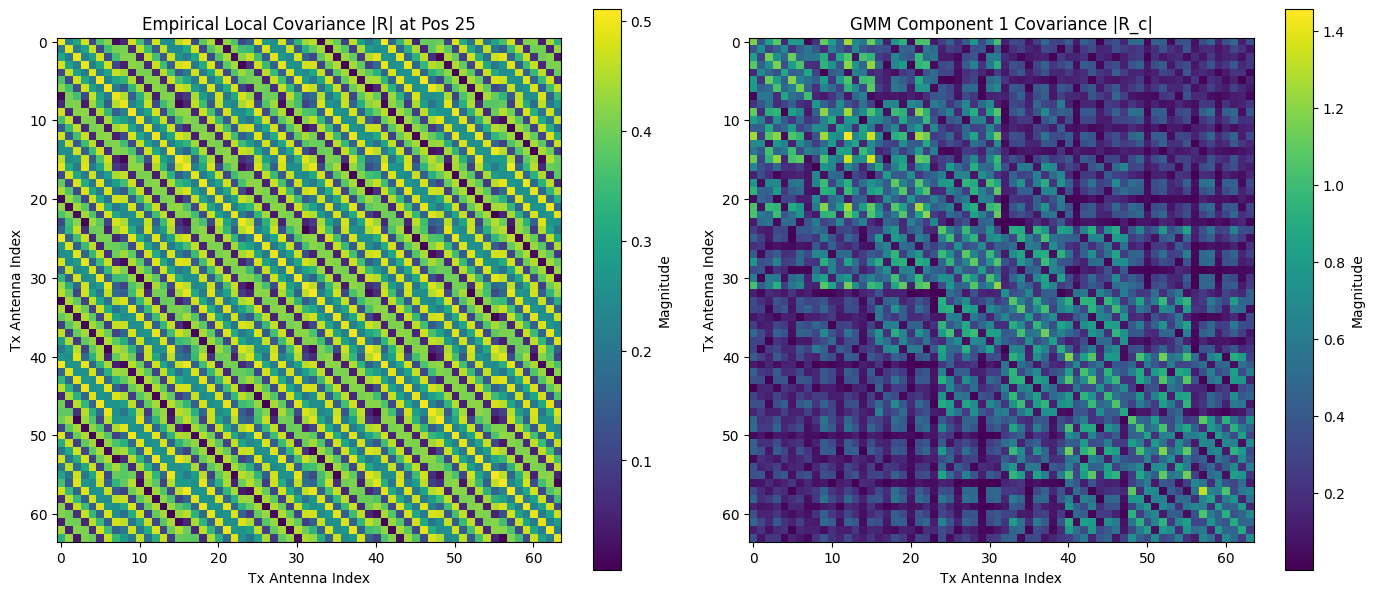

Saved dataset to data


In [11]:
# Cell 5: Visualization of Covariance Matrix Transitions and Comparison

def reconstruct_complex_cov(R_real):
    # R_real is 2N_t x 2N_t
    N_t = R_real.shape[0] // 2
    R_xx = R_real[:N_t, :N_t]
    R_xy = R_real[:N_t, N_t:]
    return 2 * (R_xx - 1j * R_xy)

# We plot the empirical covariance for a selected point and compare it with the GMM component
selected_pos = 25
c_sel = c_hat[selected_pos].item()

h_exp = tf.expand_dims(h_tensor, axis=-1)
R_per_pos = tf.matmul(h_exp, h_exp, adjoint_b=True)
R_local_emp = tf.reduce_mean(R_per_pos[selected_pos], axis=0)

# Reconstruct complex covariance for the selected state
U_c = params_em.U[c_sel].numpy()
lam_c = params_em.lam[c_sel].numpy()
R_c_real = U_c @ np.diag(lam_c) @ U_c.T
R_c_complex = reconstruct_complex_cov(R_c_real)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im0 = axes[0].imshow(np.abs(R_local_emp.numpy()), cmap="viridis")
axes[0].set_title(f"Empirical Local Covariance |R| at Pos {selected_pos}")
axes[0].set_xlabel("Tx Antenna Index")
axes[0].set_ylabel("Tx Antenna Index")
fig.colorbar(im0, ax=axes[0], label="Magnitude")

im1 = axes[1].imshow(np.abs(R_c_complex), cmap="viridis")
axes[1].set_title(f"GMM Component {c_sel} Covariance |R_c|")
axes[1].set_xlabel("Tx Antenna Index")
axes[1].set_ylabel("Tx Antenna Index")
fig.colorbar(im1, ax=axes[1], label="Magnitude")

plt.tight_layout()
plt.show()

# Export data
save_dataset(h_tensor, R_matrix)


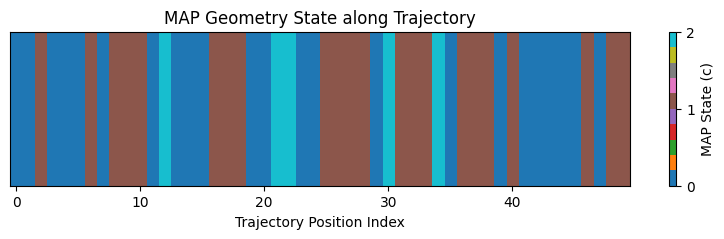

In [12]:
# Cell 6: Visualization of MAP state transitions along trajectory
plt.figure(figsize=(10, 2))
plt.imshow(c_hat.numpy()[None, :], cmap='tab10', aspect='auto')
plt.colorbar(ticks=range(K), label='MAP State (c)')
plt.title('MAP Geometry State along Trajectory')
plt.xlabel('Trajectory Position Index')
plt.yticks([])
plt.show()


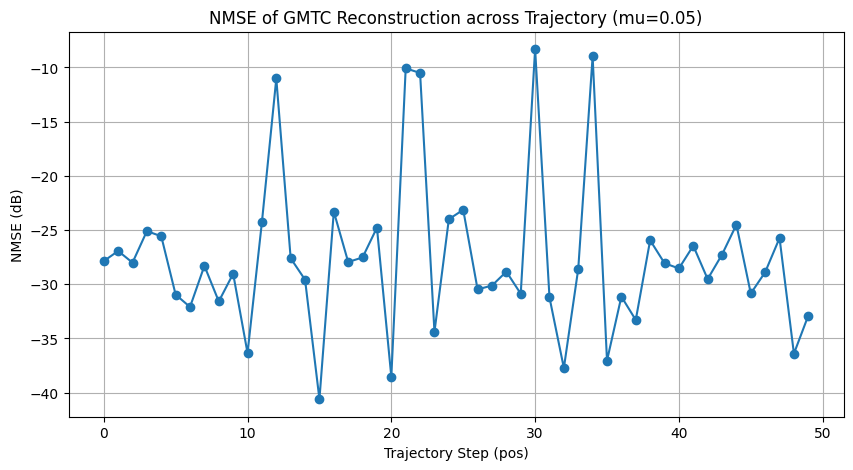

Average NMSE (dB): -27.62


In [13]:
# Cell 7: GMTC Compression, Reconstruction, and NMSE Evaluation
import numpy as np

# 1. Reconstruct complex covariances for all K states and perform eigendecomposition
K = params_em.pi.shape[0]
U_c_complex_list = []
lam_c_complex_list = []

for c in range(K):
    U_c_real = params_em.U[c].numpy()
    lam_c_real = params_em.lam[c].numpy()
    R_c_real = U_c_real @ np.diag(lam_c_real) @ U_c_real.T
    # Use the reconstruct_complex_cov from Cell 5
    R_c_comp = reconstruct_complex_cov(R_c_real)
    
    # Eigendecomposition
    evals, evecs = np.linalg.eigh(R_c_comp)
    # Sort in descending order
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]
    
    lam_c_complex_list.append(evals)
    U_c_complex_list.append(evecs)

# Prepare arrays for GMTC simulation
h_spatial_np = h_spatial.numpy() # Shape: (50, 64) complex
N_pos = h_spatial_np.shape[0]
h_hat = np.zeros_like(h_spatial_np)

# 2. Multi-Modal Reverse-Waterfilling Simulation
mu = 0.05 # Tunable water-level parameter

for t in range(N_pos):
    c_hat_t = c_hat[t].item()
    h_t = h_spatial_np[t]
    
    U_c = U_c_complex_list[c_hat_t]
    lam_c = lam_c_complex_list[c_hat_t]
    
    # Component-Matched KLT (Transform)
    h_tilde = U_c.conj().T @ h_t
    
    # Truncation via reverse-waterfilling
    mask = lam_c > mu
    h_tilde_q = h_tilde * mask
    
    # Inverse KLT (Reconstruction)
    h_hat[t] = U_c @ h_tilde_q

# 3. NMSE Calculation
nmse_linear = np.sum(np.abs(h_spatial_np - h_hat)**2, axis=1) / np.sum(np.abs(h_spatial_np)**2, axis=1)
nmse_db = 10 * np.log10(nmse_linear + 1e-12) # added epsilon for numerical stability

# 4. Visualization
plt.figure(figsize=(10, 5))
plt.plot(range(N_pos), nmse_db, marker="o", linestyle="-")
plt.title(f"NMSE of GMTC Reconstruction across Trajectory (mu={mu})")
plt.xlabel("Trajectory Step (pos)")
plt.ylabel("NMSE (dB)")
plt.grid(True)
plt.show()

print(f"Average NMSE (dB): {np.mean(nmse_db):.2f}")


/tmp/ipykernel_712058/3952497576.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


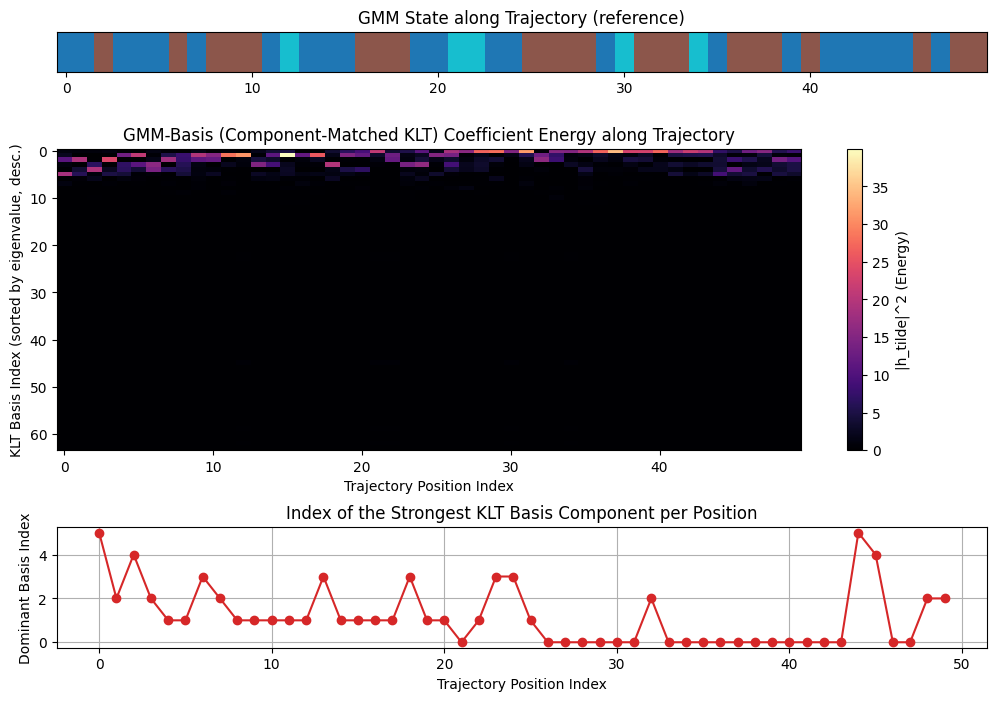

In [14]:
# Cell 8: GMM Basis (Component-Matched KLT) Trajectory Visualization
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

N_pos, N_tx = h_spatial_np.shape  # (50, 64)

# 1. 각 궤적 지점에서, 해당 지점이 속한 GMM 컴포넌트의 KLT 기저로 계수(coefficient) 계산
#    U_c_complex_list, lam_c_complex_list는 Cell 7에서 이미 계산됨 (고유값 내림차순 정렬)
basis_coeffs = np.zeros((N_pos, N_tx), dtype=np.complex64)   # KLT 계수 h_tilde
basis_energy = np.zeros((N_pos, N_tx))                        # |h_tilde|^2 (에너지)

for t in range(N_pos):
    c_t = c_hat[t].item()
    U_c = U_c_complex_list[c_t]          # (64, 64), 컴포넌트별 고유벡터
    h_t = h_spatial_np[t]
    h_tilde_t = U_c.conj().T @ h_t
    basis_coeffs[t] = h_tilde_t
    basis_energy[t] = np.abs(h_tilde_t) ** 2

# 2. 위치별 지배적 basis index (에너지가 가장 큰 성분)
dominant_basis_idx = np.argmax(basis_energy, axis=1)

# 3. Figure 구성: (a) 상태 스트립, (b) basis 계수 에너지 히트맵, (c) 지배적 basis 인덱스 변화
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(3, 1, height_ratios=[0.4, 3, 1.2], hspace=0.5)

# (a) MAP 상태 스트립 (Cell 6과 동일 정보, 참고용 정렬 기준)
ax0 = fig.add_subplot(gs[0])
ax0.imshow(c_hat.numpy()[None, :], cmap='tab10', aspect='auto',
           vmin=0, vmax=max(K - 1, 1))
ax0.set_yticks([])
ax0.set_title('GMM State along Trajectory (reference)')

# (b) Basis 계수 에너지 히트맵: y축 = basis index(고유값 내림차순), x축 = trajectory position
ax1 = fig.add_subplot(gs[1])
im = ax1.imshow(basis_energy.T, aspect='auto', cmap='magma', origin='upper')
ax1.set_xlabel('Trajectory Position Index')
ax1.set_ylabel('KLT Basis Index (sorted by eigenvalue, desc.)')
ax1.set_title('GMM-Basis (Component-Matched KLT) Coefficient Energy along Trajectory')
fig.colorbar(im, ax=ax1, label='|h_tilde|^2 (Energy)')

# (c) 지배적(top-1) basis index의 변화 추이
ax2 = fig.add_subplot(gs[2])
ax2.plot(range(N_pos), dominant_basis_idx, marker='o', linestyle='-', color='tab:red')
ax2.set_xlabel('Trajectory Position Index')
ax2.set_ylabel('Dominant Basis Index')
ax2.set_title('Index of the Strongest KLT Basis Component per Position')
ax2.grid(True)

plt.tight_layout()
plt.show()

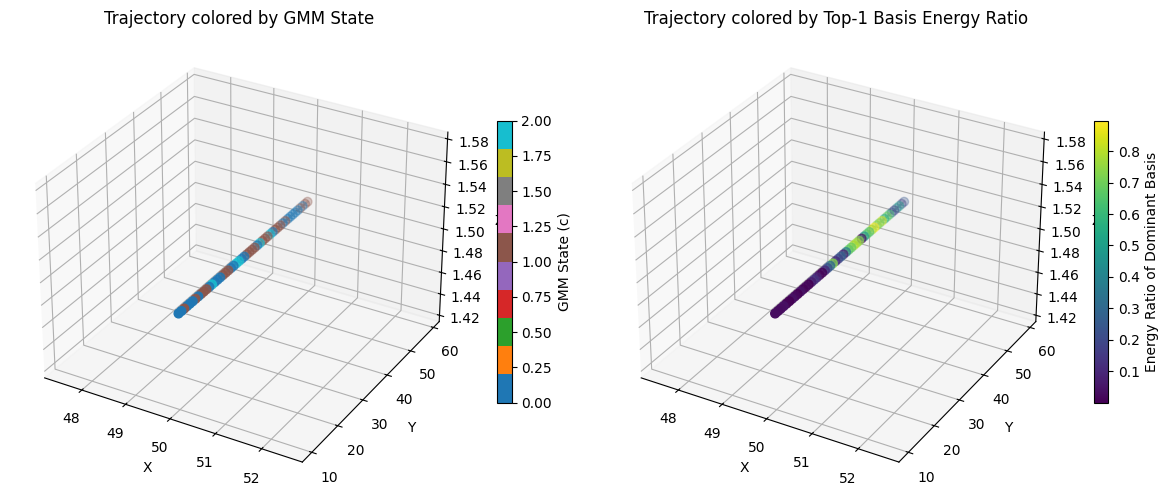

In [15]:
# Cell 9: Physical 3D Trajectory colored by GMM State / Dominant Basis Energy
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pos_np = pos_tensor.numpy() if hasattr(pos_tensor, "numpy") else np.array(pos_tensor)  # (50, 3)

fig = plt.figure(figsize=(12, 5))

# (a) GMM 상태(state)로 색칠한 3D 궤적
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(pos_np[:, 0], pos_np[:, 1], pos_np[:, 2],
                   c=c_hat.numpy(), cmap='tab10', s=40)
ax1.plot(pos_np[:, 0], pos_np[:, 1], pos_np[:, 2], color='gray', alpha=0.3)
ax1.set_title('Trajectory colored by GMM State')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
fig.colorbar(sc1, ax=ax1, shrink=0.6, label='GMM State (c)')

# (b) 최상위 basis 성분 에너지 집중도(top-1 energy ratio)로 색칠한 3D 궤적
top1_ratio = basis_energy[:, 0] / basis_energy.sum(axis=1)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(pos_np[:, 0], pos_np[:, 1], pos_np[:, 2],
                   c=top1_ratio, cmap='viridis', s=40)
ax2.plot(pos_np[:, 0], pos_np[:, 1], pos_np[:, 2], color='gray', alpha=0.3)
ax2.set_title('Trajectory colored by Top-1 Basis Energy Ratio')
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
fig.colorbar(sc2, ax=ax2, shrink=0.6, label='Energy Ratio of Dominant Basis')

plt.tight_layout()
plt.show()